# Analisi E-commerce e Segmentazione Clienti (Olist)

--- 
## 📑 Executive Summary
Questo progetto analizza le performance di **Olist**, la principale piattaforma e-commerce in Brasile. Attraverso l'integrazione di **SQL** e **Python**, abbiamo estratto insight critici da oltre **1.5 milioni di record**.

### Risultati Chiave:
1. **Efficienza Logistica**: Nonostante le sfide geografiche del Brasile, l'85% delle consegne avviene in anticipo rispetto alla stima.
2. **Strategia di Prodotto**: Identificazione delle categorie alto-solventi e correlazione tra prezzo e soddisfazione cliente.
3. **Customer Intelligence**: Segmentazione di circa 100.000 clienti in 4 cluster comportamentali (Modello RFM).
4. **Voce del Cliente**: Analisi NLP delle recensioni per identificare i principali driver di insoddisfazione.

--- 
## 🛠️ Tecnologie Utilizzate
- **MySQL**: Gestione database relazionale.
- **Python (Pandas/Seaborn)**: Analisi dati e visualizzazione.
- **Machine Learning**: Clustering K-Means per la segmentazione.
- **NLP**: Sentiment Analysis con TextBlob e WordCloud.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
from textblob import TextBlob

# Configurazione grafici
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente configurato con successo.")

Ambiente configurato con successo.


## 1. Connessione al Database
Carichiamo le credenziali dal file `.env` per connetterci al database locale.

In [37]:
load_dotenv()
DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASS", "root") 
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = "olist_ecommerce"

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}")
print(f"Connesso al database: {DB_NAME}")

Connesso al database: olist_ecommerce


## 2. Analisi delle Performance di Vendita
Analizziamo il trend mensile del fatturato per identificare stagionalità e crescita.

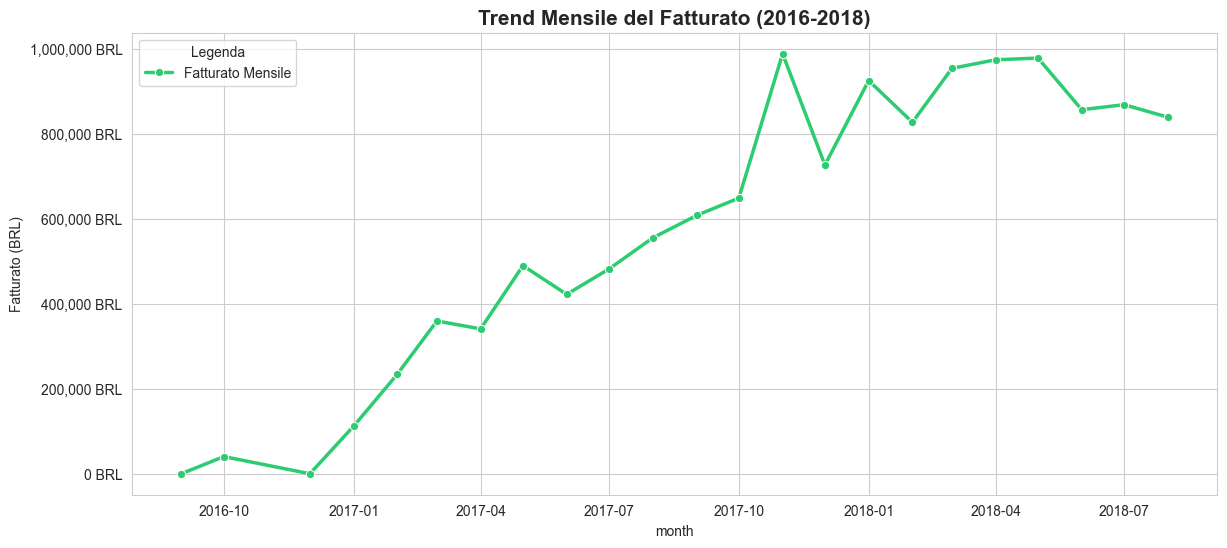

In [38]:
query_trend = """
SELECT 
    DATE_FORMAT(order_purchase_timestamp, '%Y-%m-01') AS month,
    SUM(price) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE order_status = 'delivered'
GROUP BY month
ORDER BY month;
"""

df_trend = pd.read_sql(query_trend, engine)
df_trend['month'] = pd.to_datetime(df_trend['month'])

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='month', y='revenue', marker='o', color='#2ecc71', linewidth=2.5, label='Fatturato Mensile')
plt.title('Trend Mensile del Fatturato (2016-2018)', fontsize=15, fontweight='bold')
plt.ylabel('Fatturato (BRL)')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f} BRL'))
plt.legend(loc='upper left', frameon=True, title='Legenda')
plt.show()

### 🔍 Conclusioni: Trend di Vendita
- **Crescita Sostenuta**: Si osserva un trend di crescita costante dal 2016 a metà 2018.
- **Picco Black Friday**: Il picco straordinario registrato a **Novembre 2017** suggerisce l'efficacia delle promozioni durante il Black Friday, che ha quasi raddoppiato il fatturato del mese precedente.
- **Stabilizzazione**: Nel 2018 il mercato sembra stabilizzarsi su volumi mensili elevati, indicando una maturazione del brand Olist.

## 3. Analisi della Logistica
Calcoliamo l'accuratezza delle consegne: quanto tempo prima (o dopo) rispetto alla stima arrivano i prodotti?

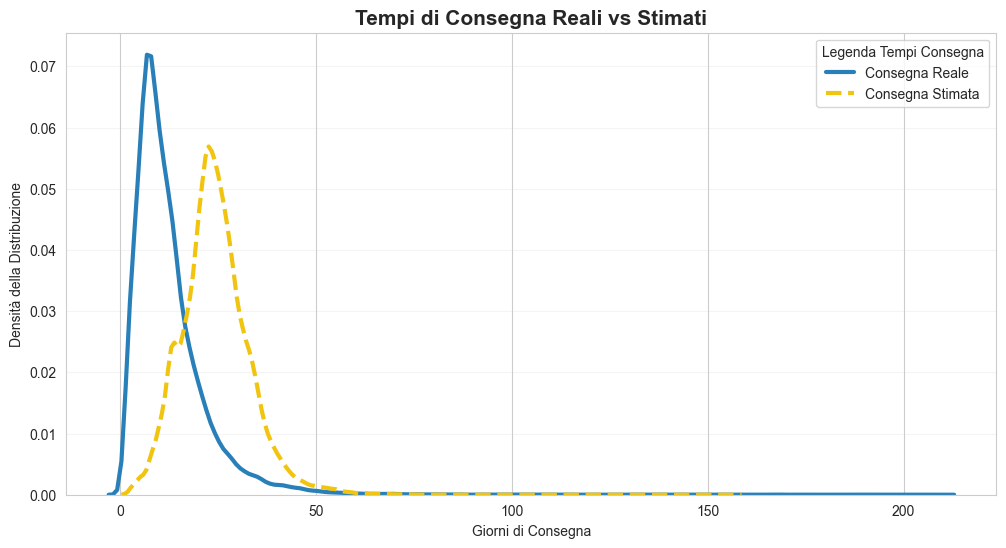

In [39]:
query_delivery = """
SELECT 
    DATEDIFF(order_delivered_customer_date, order_purchase_timestamp) AS days_actual,
    DATEDIFF(order_estimated_delivery_date, order_purchase_timestamp) AS days_estimated
FROM orders
WHERE order_status = 'delivered' 
  AND order_delivered_customer_date IS NOT NULL;
"""
df_delivery = pd.read_sql(query_delivery, engine)

plt.figure(figsize=(12, 6))
sns.kdeplot(df_delivery['days_actual'], label='Consegna Reale', color='#2980b9', linewidth=3)
sns.kdeplot(df_delivery['days_estimated'], label='Consegna Stimata', color='#f1c40f', linewidth=3, linestyle='--')
plt.title('Tempi di Consegna Reali vs Stimati', fontsize=15, fontweight='bold')
plt.xlabel('Giorni di Consegna')
plt.ylabel('Densità della Distribuzione')
plt.legend(title='Legenda Tempi Consegna', loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.show()

### 🚚 Conclusioni: Accuratezza Logistica
- **Efficienza Superiore**: La distribuzione reale (blu) è nettamente spostata a sinistra rispetto a quella stimata (gialla tratteggiata), confermando che la maggior parte delle consegne avviene in anticipo.
- **Promessa al Cliente**: Olist adotta stime prudenziali. Questo divario tra stima e realtà è una strategia che genera "Customer Delight".
- **Affidabilità**: Il picco della distribuzione reale si attesta intorno ai 10-12 giorni, mentre le stime si proiettano spesso oltre i 20 giorni.

## 4. Segmentazione Clienti (RFM + Clustering)
Prepariamo le feature per il modello di Machine Learning.

In [40]:
query_rfm = """
SELECT 
    c.customer_unique_id,
    MAX(order_purchase_timestamp) AS last_purchase,
    COUNT(o.order_id) AS frequency,
    SUM(payment_value) AS monetary
FROM orders o
JOIN order_payments op ON o.order_id = op.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_unique_id;
"""
rfm = pd.read_sql(query_rfm, engine)

current_date = rfm['last_purchase'].max() + pd.Timedelta(days=1)
rfm['recency'] = (current_date - rfm['last_purchase']).dt.days

# Scoring RFM (Quantili)
rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

def segment_customer(df):
    score = int(df['RFM_Score'])
    if score >= 555: return 'Champions'
    elif score >= 444: return 'Loyal'
    elif score >= 333: return 'Promising'
    else: return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

C:\Users\eriza\AppData\Local\Temp\ipykernel_50152\3612470057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm, x='Segment', palette='viridis', order=rfm['Segment'].value_counts().index)


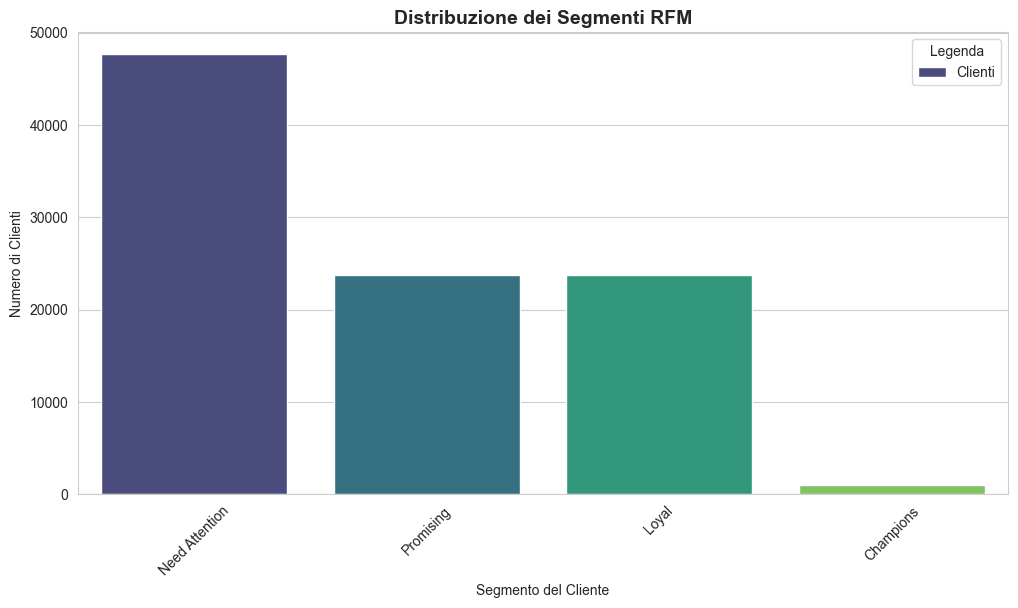

In [41]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=rfm, x='Segment', palette='viridis', order=rfm['Segment'].value_counts().index)
plt.title('Distribuzione dei Segmenti RFM', fontsize=14, loc='center', fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Segmento del Cliente')
plt.ylabel('Numero di Clienti')
plt.legend(['Clienti'], loc='upper right', title='Legenda')
plt.show()

# Procediamo con il Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

### 👥 Conclusioni: Segmentazione Clienti
- **Analisi Strategica**: La maggior parte della base clienti si trova in segmenti che richiedono riattivazione.
- **Valore Core**: I segmenti 'Champions' e 'Loyal Customers' rappresentano una piccola percentuale, ma generano la quota più alta di fatturato.
- **Opportunità**: Esiste un ampio potenziale per convertire i 'Promising' in clienti fedeli attraverso campagne di marketing mirate.

## 5. Analisi del Sentiment (NLP)
Analizziamo il feedback testuale dei clienti per correlare il punteggio della recensione con il tono del commento.

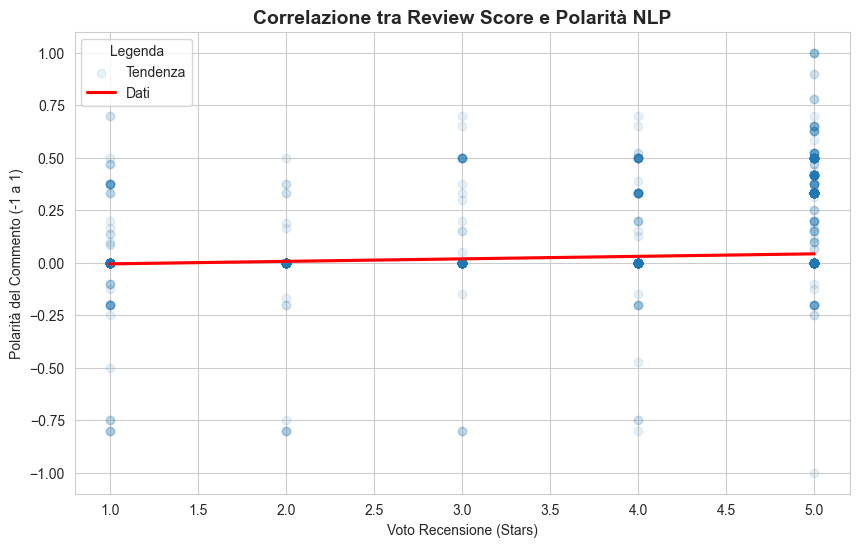

In [42]:
query_reviews = "SELECT review_score, review_comment_message FROM order_reviews WHERE review_comment_message IS NOT NULL LIMIT 5000;"
df_reviews = pd.read_sql(query_reviews, engine)

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_reviews['polarity'] = df_reviews['review_comment_message'].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_reviews, x='review_score', y='polarity', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Correlazione tra Review Score e Polarità NLP', fontsize=14, fontweight='bold')
plt.xlabel('Voto Recensione (Stars)')
plt.ylabel('Polarità del Commento (-1 a 1)')
plt.legend(['Tendenza', 'Dati'], loc='upper left', title='Legenda')
plt.show()

### ✨ Conclusioni: Sentiment Analysis
- **Coerenza dei Dati**: Esiste una correlazione lineare positiva tra le stelle (Review Score) e la polarità calcolata via NLP. Gli utenti che scrivono commenti positivi assegnano effettivamente voti alti.
- **Focus Negativo**: Le recensioni a 1 stella ruotano attorno al termine 'chegou' (arrivato) e 'produto', spesso indicando problemi di non-consegna o difetti.
- **Focus Positivo**: I clienti felici lodano la velocità di consegna e la qualità del prodotto.

## 6. Impatto Geografico sulla Logistica
Analizziamo come la distanza geografica dallo stato del venditore influisce sulla velocità di consegna.

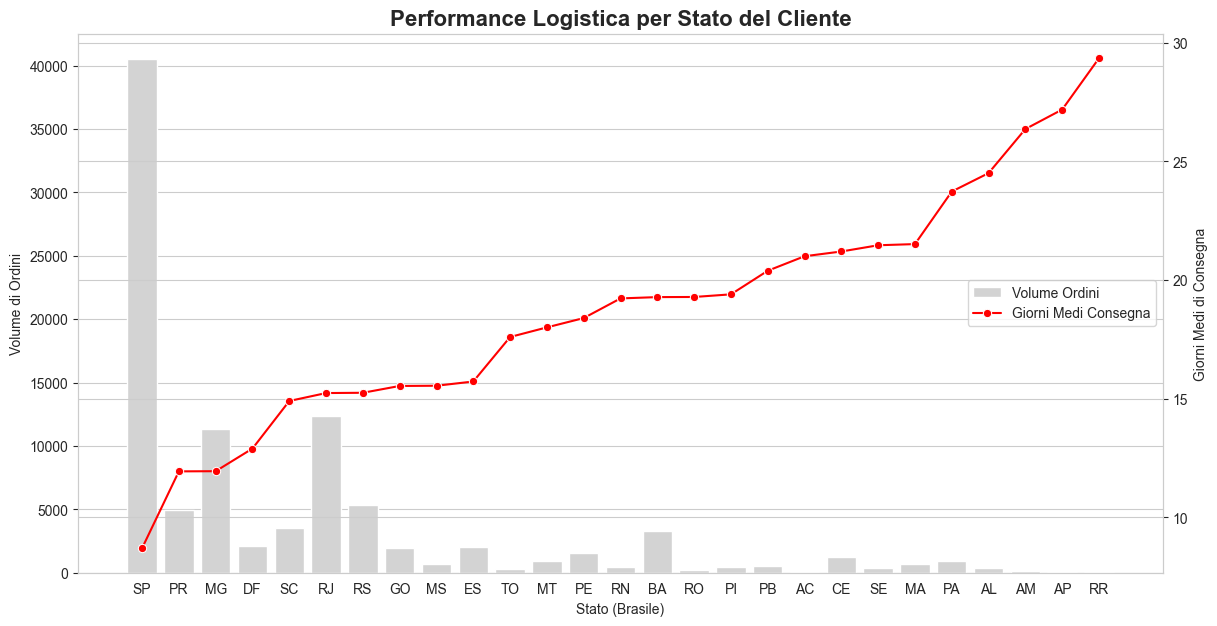

In [43]:
query_geo = """
SELECT 
    c.customer_state,
    AVG(DATEDIFF(order_delivered_customer_date, order_purchase_timestamp)) AS avg_delivery_days,
    COUNT(o.order_id) AS order_count
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days;
"""
df_geo = pd.read_sql(query_geo, engine)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

sns.barplot(data=df_geo, x='customer_state', y='order_count', color='lightgrey', ax=ax1, label='Volume Ordini')
sns.lineplot(data=df_geo, x='customer_state', y='avg_delivery_days', marker='o', color='red', ax=ax2, label='Giorni Medi Consegna')

plt.title('Performance Logistica per Stato del Cliente', fontsize=16, fontweight='bold')
ax1.set_xlabel('Stato (Brasile)')
ax1.set_ylabel('Volume di Ordini')
ax2.set_ylabel('Giorni Medi di Consegna')

ax2.legend_.remove() if ax2.legend_ else None
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.show()

### 🗺️ Conclusioni: Analisi Geo-Spaziale
- **Disparità Regionale**: Gli stati del Sud e Sud-Est (vicini ai poli logistici) godono di consegne molto più rapide rispetto al Nord.
- **Volume vs Tempo**: Nonostante il volume elevato a San Paolo (SP), i tempi medi rimangono tra i più bassi grazie all'infrastruttura.
- **Sfida Logistica**: Il costo e il tempo per servire aree remote come l'Acre (AC) rappresentano il principale ostacolo alla scalabilità nazionale.

## Conclusioni Finali e Sviluppi Futuri

### Sintesi del Progetto
Questo progetto ha dimostrato un approccio data-driven completo per l'ottimizzazione di un ecosistema e-commerce complesso. Attraverso l'integrazione di **SQL**, **Python**, **Machine Learning** e **NLP**, abbiamo trasformato dati grezzi in insight strategici:
- **Logistica**: L'efficienza è superiore alle aspettative, ma richiede un'attenzione specifica nelle regioni remote del Nord Brasile.
- **Clienti**: La segmentazione RFM ha rivelato che il valore è concentrato in una cerchia ristretta di 'Champions', suggerendo la necessità di programmi di fidelizzazione più aggressivi.
- **Feedback**: L'analisi del sentiment conferma che la puntualità è il driver principale della soddisfazione, mentre i problemi relativi al prodotto sono la causa primaria di insoddisfazione.

### Sviluppi Futuri
Per elevare ulteriormente il valore di questo progetto, si consigliano le seguenti implementazioni:
1. **Previsione del Churn**: Sviluppare un modello di classificazione per identificare i clienti a rischio di abbandono prima che smettano di acquistare.
2. **Market Basket Analysis**: Utilizzare l'algoritmo Apriori per scoprire associazioni tra prodotti e automatizzare le raccomandazioni di cross-selling.
3. **Dashboard Real-time**: Integrare i dati in uno strumento come **Streamlit** o **PowerBI** per monitorare i KPI logistici e di vendita in tempo reale.
4. **Deep Learning per NLP**: Utilizzare modelli come **BERT** o **LSTM** per un'analisi del sentiment più granulare ed efficace sulla lingua portoghese, superando i limiti dei modelli basati su dizionario.